# Classical Image Segmentation (No ML)

Segmentation partitions an image into **regions of interest** using thresholds, morphology, and geometry — no trained models.

**Image sources:** `skimage.data.coins`, `skimage.data.coffee`.

See also: `02_morphological_operations.ipynb` for open/close theory.

---

## 1. Global thresholding

**Binary threshold:** pixel → white if $I > T$, else black.

**Otsu's method:** automatically picks $T$ by maximizing between-class variance (`THRESH_OTSU`).

**Triangle method:** good when the histogram has a sharp peak and long tail (`THRESH_TRIANGLE`).

**Fixed T:** manual threshold (e.g. 127) — only works when lighting is controlled.

---

## 2. Adaptive threshold

When illumination varies across the image, a **single** global $T$ fails. Adaptive methods compute $T$ locally from a neighborhood.

| Method | OpenCV flag |
|--------|-------------|
| Mean of block | `ADAPTIVE_THRESH_MEAN_C` |
| Gaussian-weighted mean | `ADAPTIVE_THRESH_GAUSSIAN_C` |

**Algorithms in this notebook:** global & adaptive threshold (Otsu, Triangle), morphology cleanup, connected components, watershed, HSV/LAB color masks, Canny+contours, K-means, GrabCut, flood fill.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=4):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


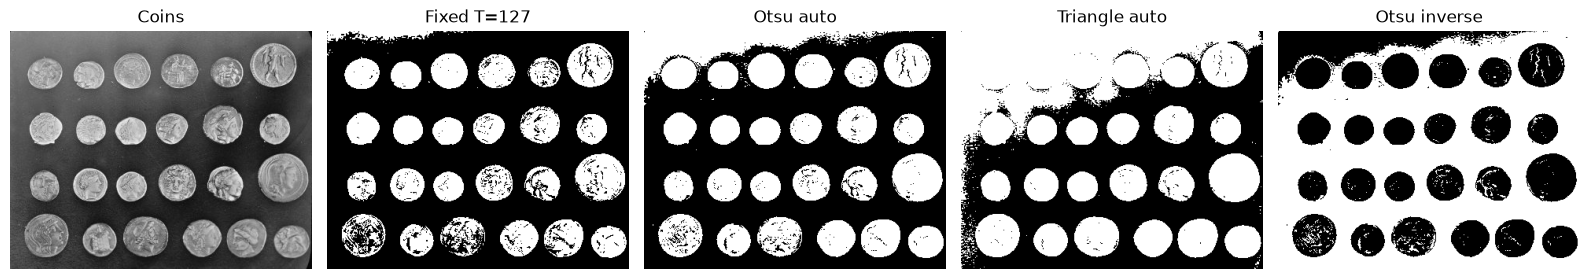

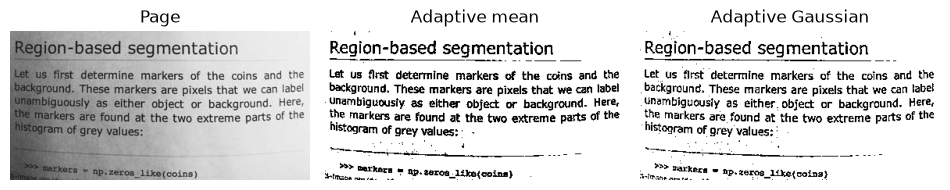

In [2]:
coins = load_sample_image("coins")
page = load_sample_image("page")

_, otsu = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_inv = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, fixed = cv2.threshold(coins, 127, 255, cv2.THRESH_BINARY)
_, triangle = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

adapt_mean = cv2.adaptiveThreshold(page, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 21, 10)
adapt_gauss = cv2.adaptiveThreshold(page, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 21, 10)

side_by_side(
    [coins, fixed, otsu, triangle, otsu_inv],
    ["Coins", "Fixed T=127", "Otsu auto", "Triangle auto", "Otsu inverse"],
    cols=5,
)
side_by_side([page, adapt_mean, adapt_gauss], ["Page", "Adaptive mean", "Adaptive Gaussian"])


## 3. Morphology cleanup

After thresholding: **opening** removes specks, **closing** fills holes (see notebook 02).


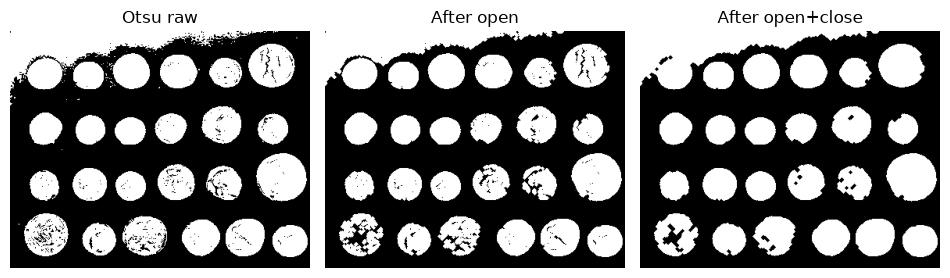

In [3]:
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opened = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, k, iterations=2)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, k, iterations=2)
side_by_side([otsu, opened, closed], ["Otsu raw", "After open", "After open+close"])

# Clean mask for watershed (§5): morphology already removed most noise; drop tiny leftovers
num_labels_c, labels_c, stats_c, centroids_c = cv2.connectedComponentsWithStats(closed, connectivity=8)
filtered = np.zeros_like(closed)
for i in range(1, num_labels_c):
    if stats_c[i, cv2.CC_STAT_AREA] >= 80:
        filtered[labels_c == i] = 255

## 4. Connected components

Label each connected blob; filter by **area** to remove small artifacts (salt specks, hole pixels).

`cv2.connectedComponentsWithStats` returns per-blob area in `stats[i, cv2.CC_STAT_AREA]`.

**Demo:** run on **raw Otsu** (before morphology) — many tiny 1–5 px specks.


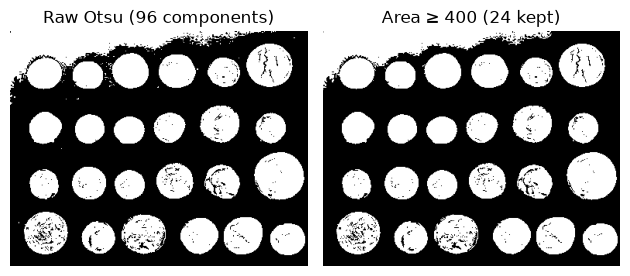

Removed 72 small blobs (specks & holes); kept 24 coin-sized regions.


In [4]:
# Demo on raw Otsu — still full of 1-pixel salt after thresholding
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(otsu, connectivity=8)
min_area = 400
filtered_demo = np.zeros_like(otsu)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        filtered_demo[labels == i] = 255

kept = sum(1 for i in range(1, num_labels) if stats[i, cv2.CC_STAT_AREA] >= min_area)
removed = (num_labels - 1) - kept

side_by_side(
    [otsu, filtered_demo],
    [f"Raw Otsu ({num_labels - 1} components)", f"Area ≥ {min_area} ({kept} kept)"],
)
print(f"Removed {removed} small blobs (specks & holes); kept {kept} coin-sized regions.")




## 5. Watershed

Separates **touching objects** using markers + gradient. We use distance transform peaks as foreground markers.

`skimage.segmentation.watershed`


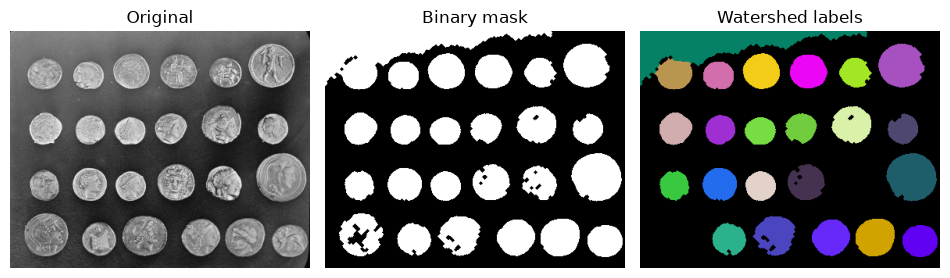

Watershed regions: 24


In [5]:
from skimage.segmentation import watershed
from scipy import ndimage

# Prepare coins for watershed
dist = cv2.distanceTransform(filtered, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.28 * dist.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)
unknown = cv2.subtract(filtered, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

labels_ws = watershed(-dist, markers, mask=filtered)
# Colorize labels
rng = np.random.default_rng(1)
colors = rng.integers(0, 255, size=(markers.max() + 2, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]
colors[1] = [0, 0, 0]
overlay = colors[labels_ws]
overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)

side_by_side([coins, filtered, overlay_bgr],
             ["Original", "Binary mask", "Watershed labels"],
             rgb_flags=[False, False, True])
print(f"Watershed regions: {labels_ws.max()}")


## 6. HSV color segmentation

Combine hue range mask + morphology for object isolation.


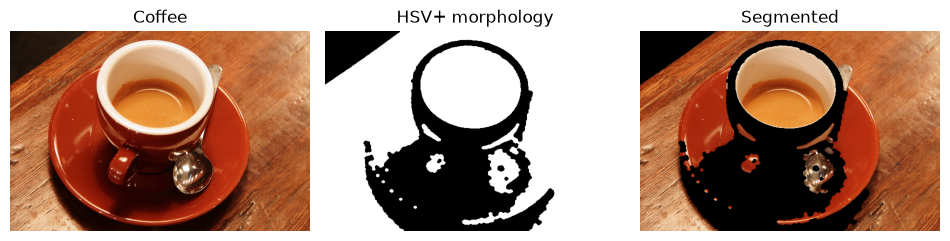

In [6]:
coffee = load_sample_image("coffee")
hsv = cv2.cvtColor(coffee, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, (5, 50, 50), (30, 255, 255))
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
result = cv2.bitwise_and(coffee, coffee, mask=mask)
side_by_side([coffee, mask, result], ["Coffee", "HSV+ morphology", "Segmented"],
             rgb_flags=[True, False, True])


## 7. Edge-based segmentation

When objects have **clear boundaries**, Canny edges + contours give a region outline without thresholding the whole image.

| Step | OpenCV |
|------|--------|
| Edge map | `cv2.Canny(gray, t1, t2)` |
| Contours | `cv2.findContours(edges, RETR_EXTERNAL, CHAIN_APPROX_SIMPLE)` |

Works best after light blur; parameters `t1`, `t2` control sensitivity.

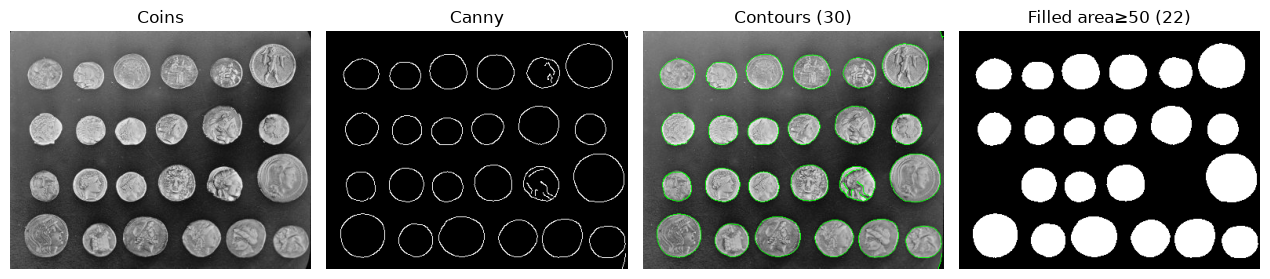

Filter contours by area to drop edge fragments.


In [7]:
# Canny + external contours on coins
blur = cv2.GaussianBlur(coins, (9,9), 2)
edges = cv2.Canny(blur, 60, 140)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

edge_vis = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
cv2.drawContours(edge_vis, contours, -1, (0, 255, 0), 1)
large = [c for c in contours if cv2.contourArea(c) >= 50]
filled = np.zeros_like(coins)
cv2.drawContours(filled, large, -1, 255, -1)

side_by_side(
    [coins, edges, edge_vis, filled],
    ["Coins", "Canny", f"Contours ({len(contours)})", f"Filled area≥50 ({len(large)})"],
    cols=4,
)
print("Filter contours by area to drop edge fragments.")

## 8. K-means color segmentation

Partition pixels into **K color clusters** in BGR space — no manual threshold.

`cv2.kmeans` → label per pixel → replace with cluster center color.

| Pros | Cons |
|------|------|
| Finds color groups automatically | Must choose K; slow on large images |
| Good for multi-colored scenes | Sensitive to lighting |

Try different `K` (3–6) on `coffee`.

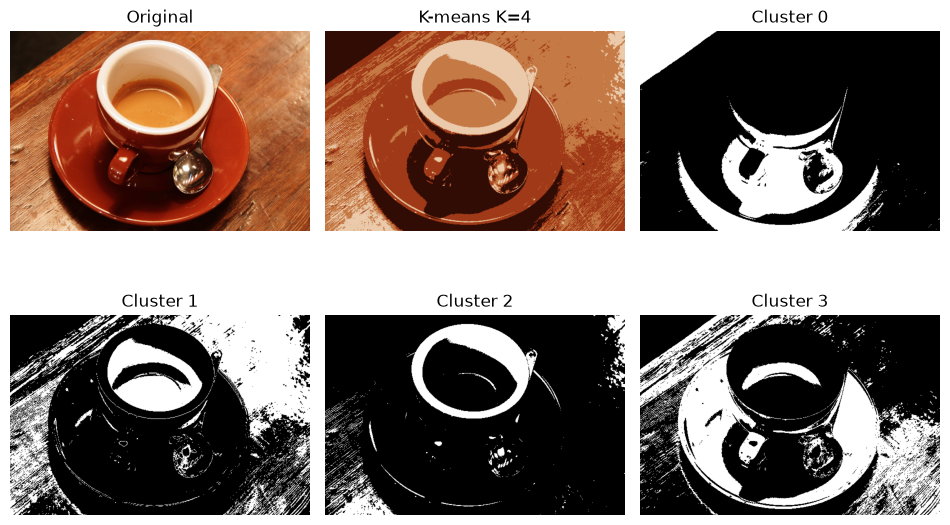

In [8]:
coffee_km = load_sample_image("coffee")
Z = coffee_km.reshape(-1, 3).astype(np.float32)
K = 4
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels_km, centers = cv2.kmeans(Z, K, None, criteria, 3, cv2.KMEANS_PP_CENTERS)
quantized = centers[labels_km.flatten()].reshape(coffee_km.shape).astype(np.uint8)

# Individual cluster masks
masks_km = []
for k in range(K):
    m = (labels_km.reshape(coffee_km.shape[:2]) == k).astype(np.uint8) * 255
    masks_km.append(m)

side_by_side(
    [coffee_km, quantized] + masks_km,
    ["Original", f"K-means K={K}"] + [f"Cluster {k}" for k in range(K)],
    rgb_flags=[True, True] + [False] * K,
    cols=3,
)

## 9. GrabCut — graph-cut segmentation

**GrabCut** separates foreground / background using color models + graph cut. Provide a **bounding box** (or mask) around the object.

`cv2.grabCut(image, mask, rect, bgdModel, fgdModel, iterCount, mode)`

| Mode | Use |
|------|-----|
| `GC_INIT_WITH_RECT` | rough box around object |
| `GC_INIT_WITH_MASK` | user scribbles (advanced) |

Output mask values: `GC_BGD`, `GC_FGD`, `GC_PR_BGD`, `GC_PR_FGD`.

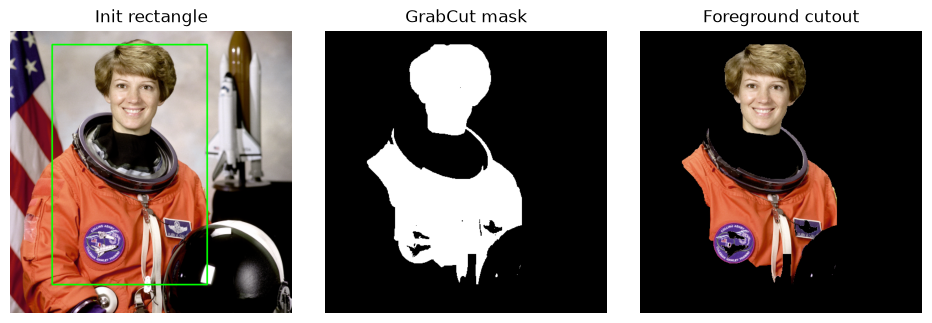

In [9]:
astronaut = load_sample_image("astronaut")
h, w = astronaut.shape[:2]
rect = (int(w * 0.15), int(h * 0.05), int(w * 0.55), int(h * 0.85))

gc_mask = np.zeros(astronaut.shape[:2], np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
cv2.grabCut(astronaut, gc_mask, rect, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_RECT)

fg = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)
grabcut_out = cv2.bitwise_and(astronaut, astronaut, mask=fg)

marked_rect = astronaut.copy()
x, y, rw, rh = rect
cv2.rectangle(marked_rect, (x, y), (x + rw, y + rh), (0, 255, 0), 2)

side_by_side(
    [marked_rect, fg, grabcut_out],
    ["Init rectangle", "GrabCut mask", "Foreground cutout"],
    rgb_flags=[True, False, True],
)

## 10. Flood fill — region growing from a seed

**Flood fill** expands from a seed pixel while neighbor intensities stay within `[−loDiff, +upDiff]`.

`cv2.floodFill(image, mask, seedPoint, newVal, loDiff, upDiff, flags)`

Useful for: filling connected regions, simple background removal, paint-bucket tools.

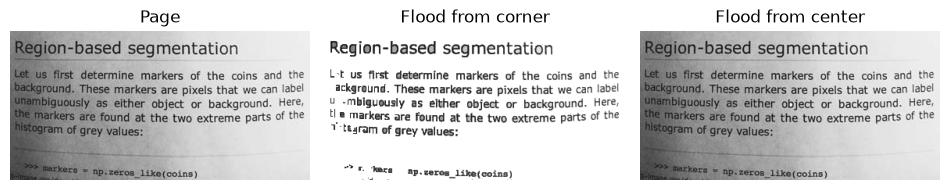

In [10]:
page_ff = load_sample_image("page")
filled = page_ff.copy()
h, w = filled.shape
ff_mask = np.zeros((h + 2, w + 2), np.uint8)
cv2.floodFill(filled, ff_mask, seedPoint=(5, 5), newVal=255, loDiff=20, upDiff=30)

filled2 = page_ff.copy()
ff_mask2 = np.zeros((h + 2, w + 2), np.uint8)
cv2.floodFill(filled2, ff_mask2, seedPoint=(w // 2, h // 2), newVal=255, loDiff=15, upDiff=15)

side_by_side(
    [page_ff, filled, filled2],
    ["Page", "Flood from corner", "Flood from center"],
)

## 11. LAB color segmentation

**LAB** separates **lightness (L)** from **color (a*, b*)**. Threshold on `a` and `b` can isolate hues more stably than RGB under lighting change.

Compare with **§6 HSV** on the same `coffee` image — different color-space geometry.

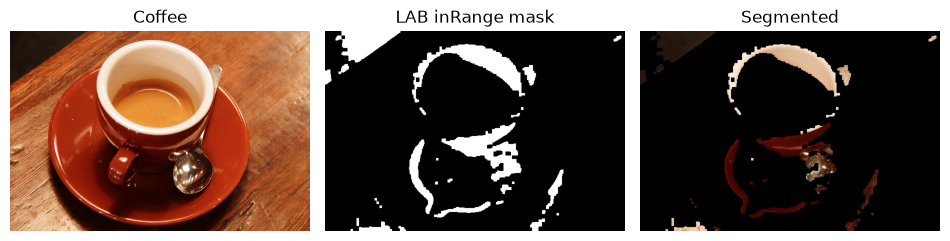

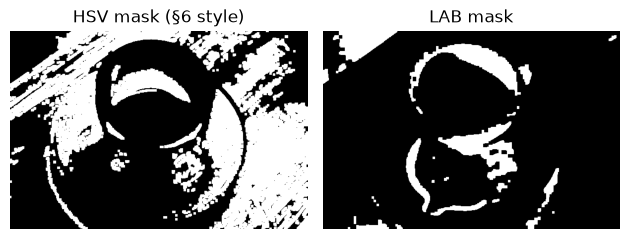

In [11]:
coffee_lab = load_sample_image("coffee")
lab_img = cv2.cvtColor(coffee_lab, cv2.COLOR_BGR2LAB)
l_ch, a_ch, b_ch = cv2.split(lab_img)

# Brown / orange cup region in LAB (tuned for skimage coffee)
lab_mask = cv2.inRange(lab_img, (20, 130, 130), (255, 165, 155))
lab_mask = cv2.morphologyEx(lab_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
lab_mask = cv2.morphologyEx(lab_mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
lab_result = cv2.bitwise_and(coffee_lab, coffee_lab, mask=lab_mask)

side_by_side(
    [coffee_lab, lab_mask, lab_result],
    ["Coffee", "LAB inRange mask", "Segmented"],
    rgb_flags=[True, False, True],
)

# HSV vs LAB side-by-side (reuse §6 idea)
hsv_cmp = cv2.cvtColor(coffee_lab, cv2.COLOR_BGR2HSV)
hsv_mask_cmp = cv2.inRange(hsv_cmp, (5, 80, 40), (25, 255, 200))
hsv_mask_cmp = cv2.morphologyEx(hsv_mask_cmp, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
side_by_side(
    [hsv_mask_cmp, lab_mask],
    ["HSV mask (§6 style)", "LAB mask"],
)

## 12. Summary

| Method | Input | Output | When to use |
|--------|-------|--------|-------------|
| Fixed / Otsu / Triangle threshold | Gray | Binary | bimodal histogram |
| Adaptive threshold | Gray | Binary | uneven lighting (`page`) |
| Morphology open/close | Binary | Clean binary | remove specks, fill holes |
| Connected components | Binary | Labels / filtered blobs | count objects, drop noise |
| Watershed | Binary + markers | Separated instances | touching coins |
| HSV / LAB inRange | Color | Mask | object by hue/color |
| Canny + contours | Gray | Boundaries / filled regions | strong edges |
| K-means | Color | K segment labels | auto color grouping |
| GrabCut | Color + rect | FG/BG mask | interactive cutout |
| Flood fill | Gray + seed | Filled region | connected area from point |

**Pipeline recipe:** threshold → morphology → (optional) CC filter → measure or watershed.
